# RRT Demo: Fast Feasible Path Search

This notebook teaches RRT (Rapidly-exploring Random Tree) as a practical first-solution planner.

What you will learn:
- how random sampling grows a search tree from the start,
- how step size and goal bias change exploration behavior,
- why RRT is often fast but not cost-optimal.

How to use this notebook:
1. Run cells in order.
2. Inspect tree shape before judging path quality.
3. Experiment with `goal_bias`, `step_len`, and `max_iters`.

In [1]:
%matplotlib inline

import math
import random

import matplotlib.pyplot as plt
import numpy as np

## 1. Build the map and define start/goal

We create an occupancy grid with narrow passages to make random exploration meaningful.

In [2]:
H, W = 60, 60
grid = np.zeros((H, W), dtype=np.uint8)

grid[8:52, 22] = 1
grid[8:52, 38] = 1
grid[30, 22:39] = 1
grid[16, 22] = 0
grid[44, 38] = 0
grid[30, 30] = 0

start = (5.0, 5.0)
goal = (55.0, 55.0)

## 2. Geometry utilities and collision checks

RRT repeatedly proposes short edges, so reliable edge collision tests are essential.

In [3]:
def in_bounds(r, c):
    return 0 <= r < H and 0 <= c < W

def free_point(p):
    r, c = int(round(p[0])), int(round(p[1]))
    return in_bounds(r, c) and grid[r, c] == 0

def dist(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])

def line_free(a, b):
    n = int(max(abs(b[0] - a[0]), abs(b[1] - a[1]))) + 1
    for i in range(n + 1):
        t = i / max(1, n)
        p = (a[0] + t * (b[0] - a[0]), a[1] + t * (b[1] - a[1]))
        if not free_point(p):
            return False
    return True

## 3. Run the RRT growth loop

This is the core algorithm loop.
- sample random targets (with occasional goal bias),
- extend from nearest node by one step,
- keep only collision-free additions.

Observe: a larger goal bias can speed up reaching the goal, but may reduce broad exploration.

RRT naturally tends to grow toward unexplored regions because nodes with larger unexplored neighborhoods are more likely to be selected as nearest neighbors for future samples.

In [16]:
rng = random.Random(13)
step_len = 2.0
goal_radius = 2.5
goal_bias = 0.12
max_iters = 3000

nodes = [start]
parent = {0: None}
goal_idx = None

for _ in range(max_iters):
    if rng.random() < goal_bias:
        sample = goal
    else:
        sample = (rng.uniform(0, H - 1), rng.uniform(0, W - 1))

    near_i = min(range(len(nodes)), key=lambda i: dist(nodes[i], sample))
    near = nodes[near_i]

    d = dist(near, sample)
    if d < 1e-9:
        continue

    t = min(step_len / d, 1.0)
    new = (near[0] + t * (sample[0] - near[0]), near[1] + t * (sample[1] - near[1]))

    if not free_point(new):
        continue
    if not line_free(near, new):
        continue

    nodes.append(new)
    ni = len(nodes) - 1
    parent[ni] = near_i

    if dist(new, goal) <= goal_radius and line_free(new, goal):
        nodes.append(goal)
        gi = len(nodes) - 1
        parent[gi] = ni
        goal_idx = gi
        break

print('Nodes in tree:', len(nodes), 'Found path:', goal_idx is not None)

Nodes in tree: 354 Found path: True


## 4. Extract and inspect the found path

If `goal_idx` is connected, we backtrack using the parent pointers to recover the route.

In [17]:
path = []
if goal_idx is not None:
    cur = goal_idx
    while cur is not None:
        path.append(nodes[cur])
        cur = parent[cur]
    path.reverse()

print('Path points:', len(path))

Path points: 59


## 5. Visual interpretation and self-check

Read the final plot with these questions:
- Is the tree spread balanced or strongly biased?
- Does the path look jagged (common for plain RRT)?
- What changes if you halve or double `step_len`?

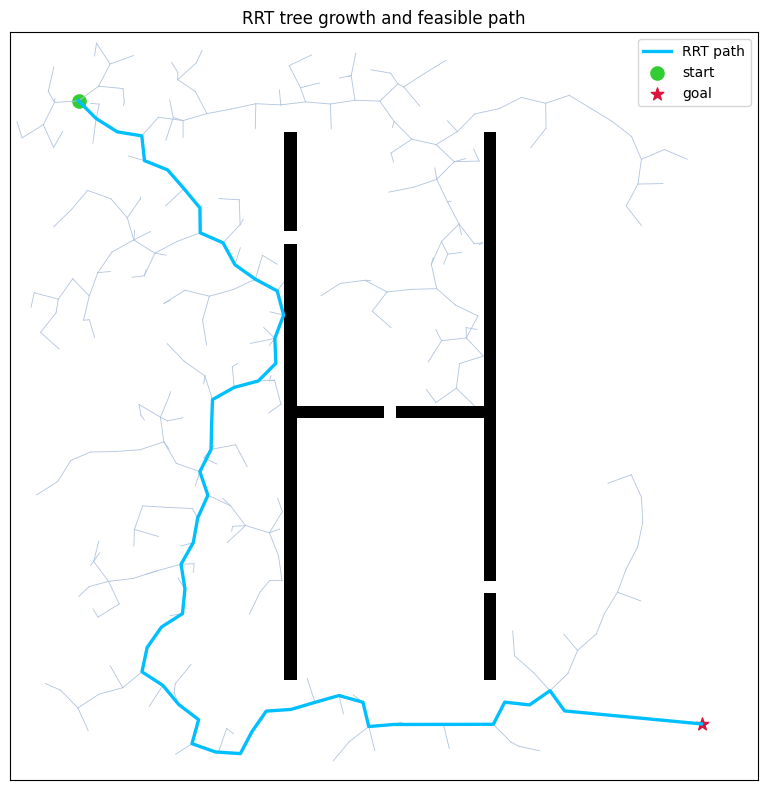

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(grid, cmap='Greys', origin='upper')

for i in range(1, len(nodes)):
    pi = parent[i]
    if pi is None:
        continue
    a, b = nodes[pi], nodes[i]
    ax.plot([a[1], b[1]], [a[0], b[0]], color='lightsteelblue', linewidth=0.6)

if path:
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='deepskyblue', linewidth=2.4, label='RRT path')

ax.scatter(start[1], start[0], c='limegreen', s=90, marker='o', label='start')
ax.scatter(goal[1], goal[0], c='crimson', s=90, marker='*', label='goal')
ax.set_title('RRT tree growth and feasible path')
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()